In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.model import SimpleTransformer
from src.dataset import generate_ou_process
from src.inference import extract_trajectory_statistics

In [26]:
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], cfg['paths']['next_token_model_name'])

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Loaded next-token model from {model_path}")
else:
    raise FileNotFoundError(f"Model not found at {model_path}. Train with mode 1 (next-token) first.")

Loaded next-token model from ../experiments/model_next_token.pth


In [27]:
multi_cfg = cfg['multi_mean']
num_trajectories = 200
mean_min = multi_cfg['mean_min']
mean_max = multi_cfg['mean_max']
random_means = np.random.uniform(mean_min, mean_max, num_trajectories)

all_trajectories = []
all_actual_means = []

for mu in random_means:
    traj = generate_ou_process(
        batch_size=1,
        time_steps=cfg['generation']['total_time_steps'],
        theta=cfg['physics']['theta'],
        mu=float(mu),
        sigma=cfg['physics']['sigma'],
        dt=cfg['physics']['dt']
    )
    all_trajectories.append(traj)
    all_actual_means.append(mu)

all_trajectories = torch.cat(all_trajectories, dim=0)
all_actual_means = np.array(all_actual_means)

print(f"Generated {len(all_trajectories)} trajectories with random means in [{mean_min}, {mean_max}]")

Generated 200 trajectories with random means in [-1.5, 1.5]


In [28]:
# Extract mean and variance using algebraic method
predicted_means = []
predicted_variances = []

for i in range(0, len(all_trajectories), 20):
    batch = all_trajectories[i:i+20]
    mu_ext, var_ext = extract_trajectory_statistics(
        model, batch, cfg['physics']['theta'], cfg['physics']['dt'], device
    )
    predicted_means.extend(mu_ext.numpy())
    predicted_variances.extend(var_ext.numpy())

predicted_means = np.array(predicted_means)
predicted_variances = np.clip(np.array(predicted_variances), 0, None)

theta = cfg['physics']['theta']
sigma = cfg['physics']['sigma']
theoretical_var = (sigma ** 2) / (2 * theta)
empirical_variances = np.array([traj.squeeze().var().item() for traj in all_trajectories])

print(f"Extracted statistics for {len(predicted_means)} trajectories")
print(f"Mean MAE: {np.abs(predicted_means - all_actual_means).mean():.4f}")
print(f"Theoretical variance: {theoretical_var:.4f}")

Extracted statistics for 200 trajectories
Mean MAE: 30.8433
Theoretical variance: 0.1333


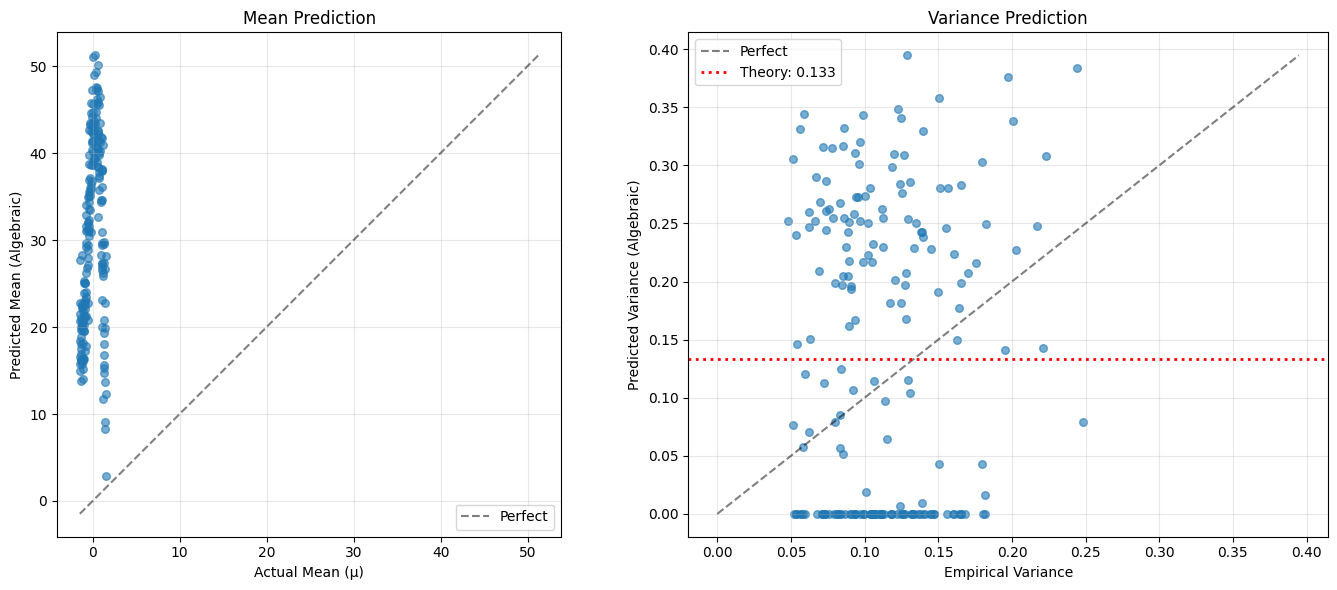

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean prediction
ax = axes[0]
ax.scatter(all_actual_means, predicted_means, alpha=0.6, s=30)
min_val = min(all_actual_means.min(), predicted_means.min())
max_val = max(all_actual_means.max(), predicted_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('Actual Mean (μ)')
ax.set_ylabel('Predicted Mean (Algebraic)')
ax.set_title('Mean Prediction')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Variance prediction
ax = axes[1]
ax.scatter(empirical_variances, predicted_variances, alpha=0.6, s=30)
v_min = min(empirical_variances.min(), predicted_variances.min())
v_max = max(empirical_variances.max(), predicted_variances.max())
ax.plot([v_min, v_max], [v_min, v_max], 'k--', alpha=0.5, label='Perfect')
ax.axhline(y=theoretical_var, color='red', linestyle=':', linewidth=2, label=f'Theory: {theoretical_var:.3f}')
ax.set_xlabel('Empirical Variance')
ax.set_ylabel('Predicted Variance (Algebraic)')
ax.set_title('Variance Prediction')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

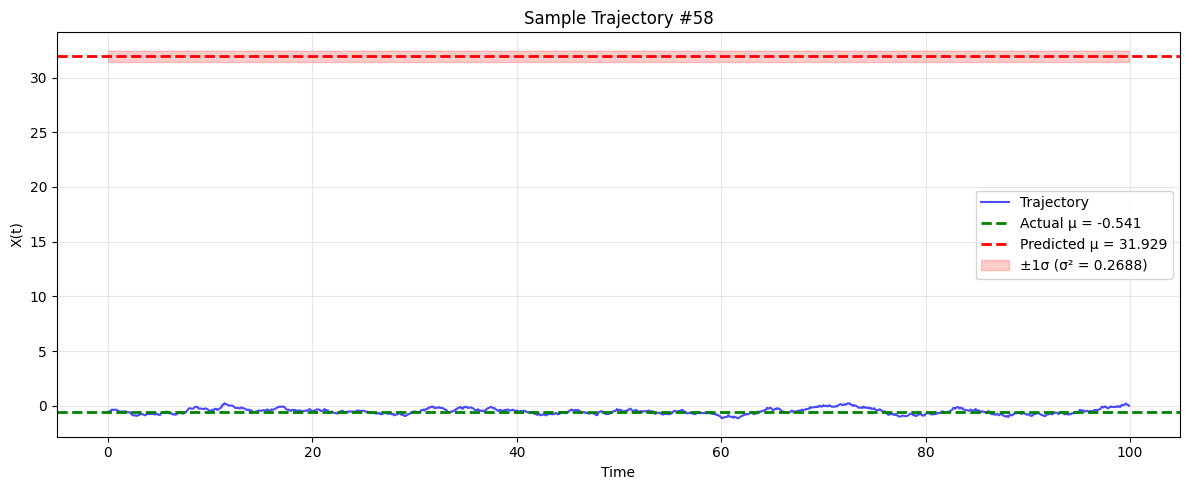

In [30]:
idx = np.random.randint(0, len(all_trajectories))
traj = all_trajectories[idx].squeeze().cpu().numpy()
actual_mean = all_actual_means[idx]
pred_mean = predicted_means[idx]
pred_var = predicted_variances[idx]

timestamps = np.arange(len(traj)) * cfg['physics']['dt']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(timestamps, traj, 'b-', alpha=0.7, label='Trajectory')
ax.axhline(y=actual_mean, color='green', linestyle='--', linewidth=2, label=f'Actual μ = {actual_mean:.3f}')
ax.axhline(y=pred_mean, color='red', linestyle='--', linewidth=2, label=f'Predicted μ = {pred_mean:.3f}')
ax.fill_between(timestamps, pred_mean - np.sqrt(pred_var), pred_mean + np.sqrt(pred_var), 
                 color='red', alpha=0.2, label=f'±1σ (σ² = {pred_var:.4f})')
ax.set_xlabel('Time')
ax.set_ylabel('X(t)')
ax.set_title(f'Sample Trajectory #{idx}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()